# Retail Sales Data — Exploratory Data Analysis (EDA)

## Internship Project Submission

### Objective
Perform Exploratory Data Analysis on retail transaction data to understand sales trends, customer behaviour, product-category performance, and actionable business insights.

### Tools & Technologies
- Python
- pandas
- NumPy
- Matplotlib
- Jupyter Notebook

### Project Workflow
1. Import libraries
2. Load and inspect the dataset
3. Check data quality
4. Generate descriptive statistics
5. Prepare and transform data
6. Analyze sales trends
7. Analyze customer demographics
8. Analyze product-category performance
9. Study numerical relationships
10. Present business insights and recommendations

> **Compatibility note:** This project uses Matplotlib only for visualization. Seaborn is not required, so `sns.set_theme()` errors are avoided.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Dataset

In [2]:
import os

data_path = "retail_sales_dataset.csv"
if not os.path.exists(data_path):
    data_path = "/mnt/data/retail_sales_dataset.csv"

if not os.path.exists(data_path):
    raise FileNotFoundError("retail_sales_dataset.csv was not found.")

df = pd.read_csv(data_path)
print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()


Dataset loaded successfully.
Rows: 1000
Columns: 9


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100


## 3. Initial Data Inspection

The dataset is inspected for its dimensions, column names, data types, missing values, and duplicate records before analysis.


In [3]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Shape: (1000, 9)

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate rows: 0


## 4. Descriptive Statistics

In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns

statistics = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Mode": df[numeric_cols].mode().iloc[0],
    "Standard Deviation": df[numeric_cols].std()
})

statistics


,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


### Observation
Mean and median describe central tendency, mode identifies the most frequent value, and standard deviation shows the amount of variation in numerical variables.


## 5. Data Preparation

In [5]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

# Remove records where Date could not be interpreted.
df = df.dropna(subset=["Date"]).copy()

df["YearMonth"] = df["Date"].dt.to_period("M")
df["Quarter"] = df["Date"].dt.to_period("Q")

bins = [0, 18, 25, 35, 45, 55, 100]
labels = ["0-18", "19-25", "26-35", "36-45", "46-55", "55+"]
df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

print("Data preparation completed.")
df.head()


Data preparation completed.


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,YearMonth,Quarter,Age_Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11,2023Q4,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02,2023Q1,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01,2023Q1,46-55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05,2023Q2,36-45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05,2023Q2,26-35


## 6. Monthly Sales Trend

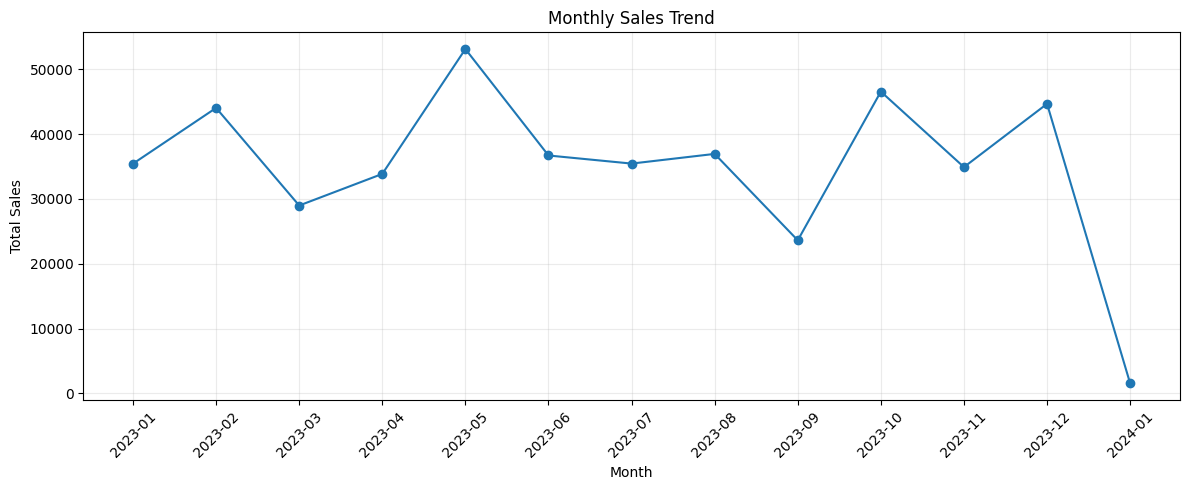

Highest-sales month: 2023-05 with total sales = 53150


In [6]:
monthly_sales = df.groupby("YearMonth")["Total Amount"].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Highest-sales month:", monthly_sales.idxmax(), "with total sales =", monthly_sales.max())


### Business Interpretation
The monthly trend shows how sales change over time. Higher-sales periods can be used for inventory planning, staffing, and promotional campaigns.


## 7. Quarterly Sales Trend

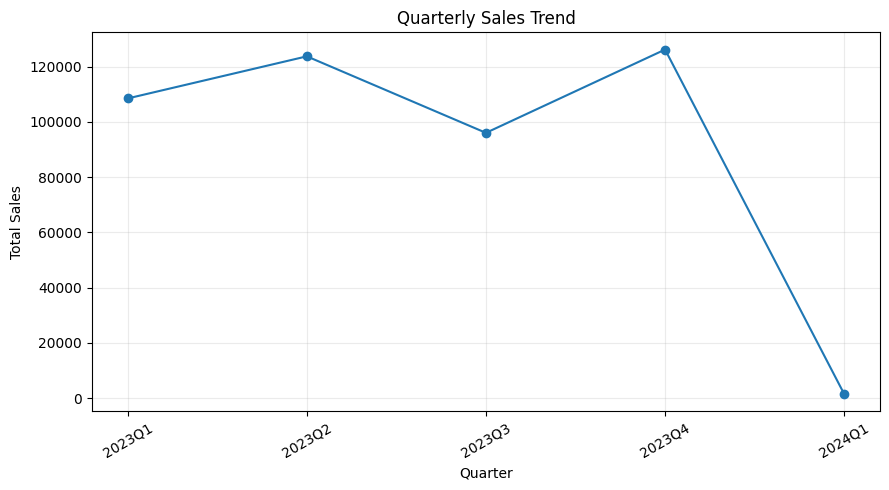

Highest-sales quarter: 2023Q4 with total sales = 126190


In [7]:
quarterly_sales = df.groupby("Quarter")["Total Amount"].sum()

plt.figure(figsize=(9, 5))
plt.plot(quarterly_sales.index.astype(str), quarterly_sales.values, marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Highest-sales quarter:", quarterly_sales.idxmax(), "with total sales =", quarterly_sales.max())


### Business Interpretation
Quarterly analysis provides a broader view of sales performance and can help management plan resources and campaigns for stronger and weaker periods.


## 8. Customer Age Group Distribution

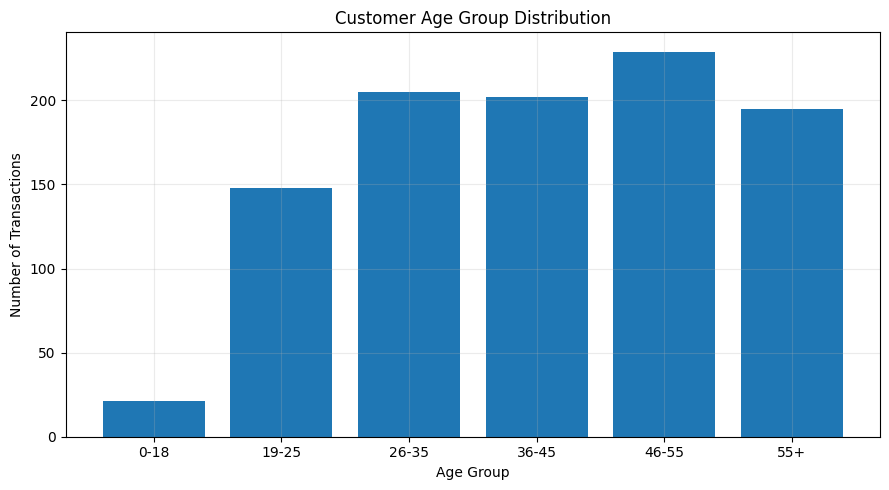

Age_Group
0-18      21
19-25    148
26-35    205
36-45    202
46-55    229
55+      195
Name: count, dtype: int64


In [8]:
age_counts = df["Age_Group"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
plt.bar(age_counts.index.astype(str), age_counts.values)
plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

print(age_counts)


### Business Interpretation
The age-group distribution identifies the customer segments most represented in the dataset and can support targeted marketing decisions.


## 9. Gender Distribution

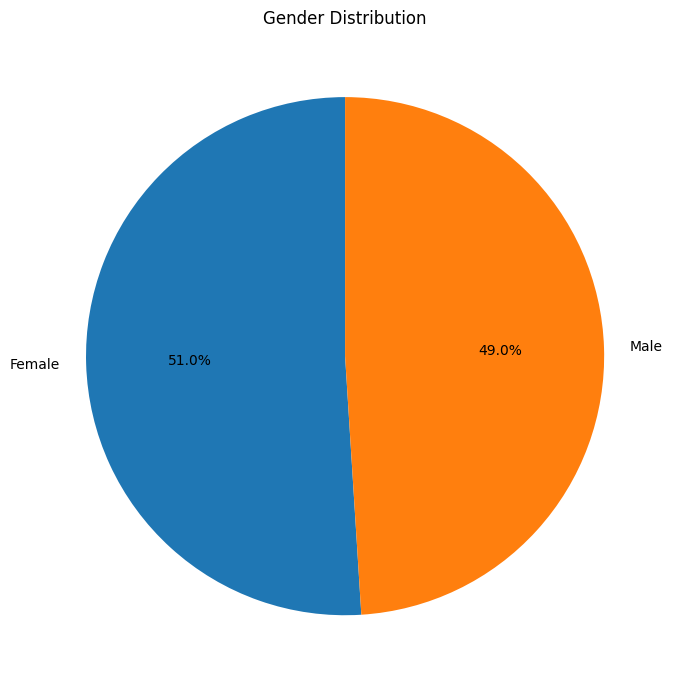

Gender
Female    510
Male      490
Name: count, dtype: int64


In [9]:
gender_count = df["Gender"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

print(gender_count)


### Business Interpretation
The gender distribution shows the relative representation of customer transactions by gender and can be used as one factor in customer-segment analysis.


## 10. Product Category Performance

The dataset contains a **Product Category** field rather than individual product names. Therefore, category-level analysis is used instead of claiming an individual Top 10 Product ranking.


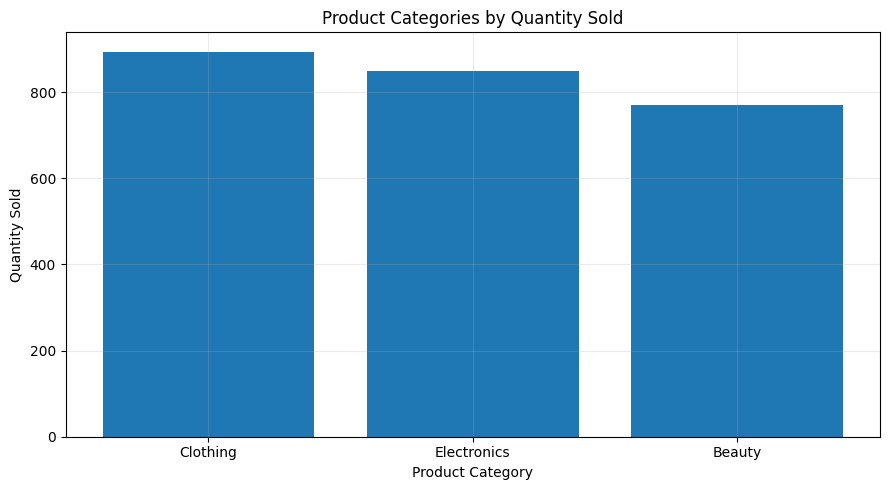

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


In [10]:
category_quantity = (
    df.groupby("Product Category")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(category_quantity.index.astype(str), category_quantity.values)
plt.title("Product Categories by Quantity Sold")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.tight_layout()
plt.show()

print(category_quantity)


### Business Interpretation
Categories with higher quantities sold indicate stronger demand and should receive appropriate inventory attention.


## 11. Revenue by Product Category

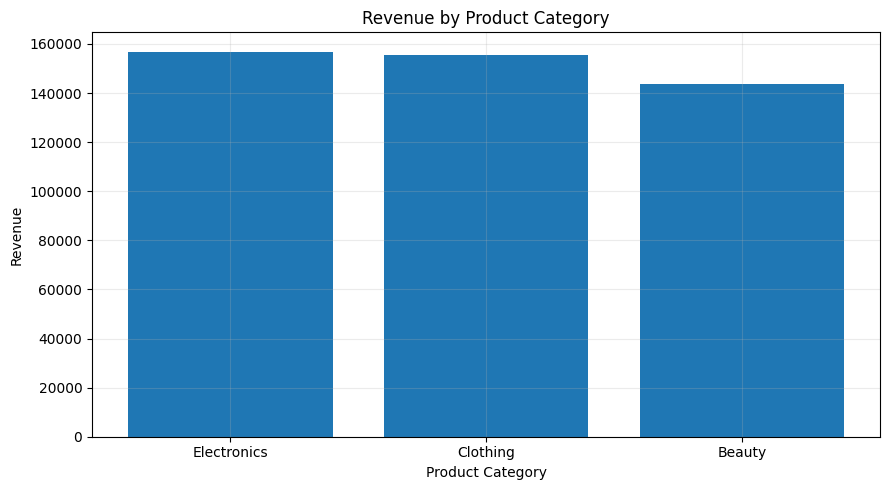

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


In [11]:
category_revenue = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
plt.bar(category_revenue.index.astype(str), category_revenue.values)
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

print(category_revenue)


### Business Interpretation
Revenue ranking highlights which product categories contribute most to overall sales value. High-revenue categories can be prioritized for availability and marketing.


## 12. Correlation Heatmap

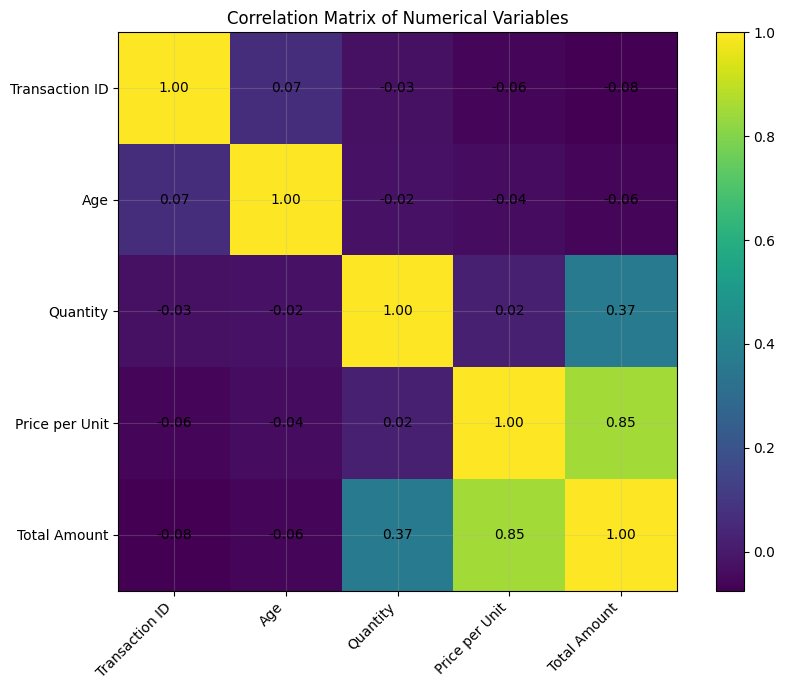

In [12]:
correlation = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(9, 7))
plt.imshow(correlation, interpolation="nearest")
plt.colorbar()
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

for i in range(len(correlation.index)):
    for j in range(len(correlation.columns)):
        plt.text(
            j, i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()


### Business Interpretation
The correlation matrix helps identify relationships between numerical variables such as age, quantity, price per unit, and total transaction amount.


## 13. Average Spending by Age Group

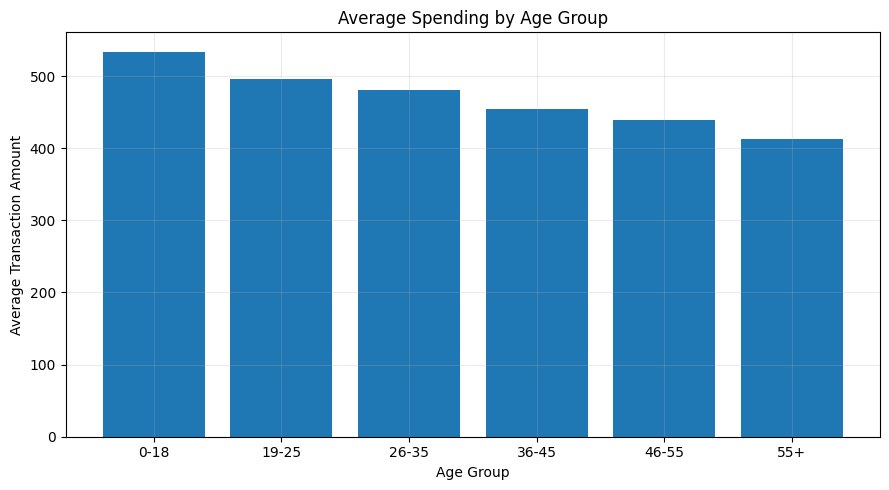

Age_Group
0-18     534.047619
19-25    495.506757
26-35    480.390244
36-45    454.801980
46-55    439.694323
55+      412.358974
Name: Total Amount, dtype: float64


In [13]:
age_spending = (
    df.groupby("Age_Group", observed=True)["Total Amount"]
      .mean()
)

plt.figure(figsize=(9, 5))
plt.bar(age_spending.index.astype(str), age_spending.values)
plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Amount")
plt.tight_layout()
plt.show()

print(age_spending)


### Business Interpretation
Average transaction value by age group gives additional information beyond customer counts and helps identify segments with relatively higher spending per transaction.


## 14. Revenue by Gender

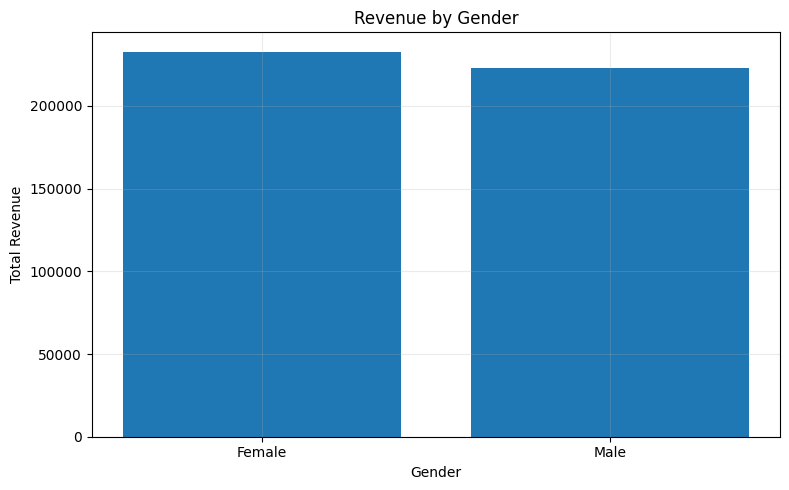

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


In [14]:
gender_revenue = (
    df.groupby("Gender")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(gender_revenue.index.astype(str), gender_revenue.values)
plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

print(gender_revenue)


### Business Interpretation
Revenue by gender provides another customer-segment view and can be considered alongside transaction counts and age-group spending when planning customer-focused campaigns.


# 15. Key Findings

- The dataset contains retail transaction records covering customer demographics, product categories, quantity, price per unit, and transaction amount.
- Monthly and quarterly trends show how sales vary over time.
- Age-group analysis identifies the most represented customer segments.
- Gender analysis shows the distribution and revenue contribution of customer transactions.
- Product-category analysis identifies categories with stronger quantity demand and revenue contribution.
- Correlation analysis provides a numerical view of relationships among sales-related variables.
- Average spending by age group helps identify differences in transaction value between customer segments.

# 16. Actionable Business Recommendations

1. **Improve inventory planning:** Maintain sufficient stock for high-demand product categories.
2. **Use sales trends:** Plan promotions, staffing, and inventory around stronger sales periods.
3. **Target customer segments:** Use age and gender patterns to design more relevant campaigns.
4. **Prioritize high-revenue categories:** Protect availability and marketing support for categories contributing strongly to revenue.
5. **Monitor customer spending:** Repeat this EDA periodically to identify changes in customer behaviour.
6. **Collect product-level information:** Adding individual product names would allow detailed Top Product analysis in future.

# 17. Conclusion

This project demonstrates a complete Exploratory Data Analysis workflow using Python, pandas, NumPy, and Matplotlib. The analysis moves from data-quality checking and descriptive statistics to sales trends, customer segmentation, category performance, relationship analysis, and business recommendations.

The project provides a practical example of how raw retail transaction data can be converted into understandable visual insights that support business decision-making.

## Dataset Limitation

The supplied dataset contains **Product Category** but does not provide individual product names. Therefore, the analysis correctly focuses on product-category performance rather than inventing individual product rankings.
